# Evaluación 3 · Sección 7 — Contrastes y primer modelo

Continuación de `Contreras_Daniela-Nicklichen_Emanuel_Evaluacion_3_S6_Base.ipynb`.

**Alcance de este notebook:** contrastar la hipótesis tal como fue formulada, responder la dimensión socioeconómica que quedó pendiente, y ajustar el primer modelo del proyecto con su incertidumbre.

**Sobre el entorno:** se incorpora `statsmodels` al proyecto por el uso de regresión logística y de Poisson. Queda registrado en `pyproject.toml` y `uv.lock`, con el mismo criterio de reproducibilidad declarado en S0.

## 7.1 Carga de la base

Este notebook no recalcula nada: lee la tabla que produjo la Sección 6.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportion_confint, proportions_ztest

DIRECTORIO_ACTUAL = Path.cwd()
DIRECTORIO_RAIZ = DIRECTORIO_ACTUAL.parent
RUTA_BASE = DIRECTORIO_RAIZ / "data" / "processed" / "base_no_seleccionados.csv"

base = pd.read_csv(RUTA_BASE)

# Orden fijo de dependencias, de menor a mayor selectividad del establecimiento.
# La primera categoria es la referencia de los modelos.
ORDEN_DEP = ["Municipal","Corp. Municipal","SLEP","Corp. Adm. Delegada",
             "Part. Subvencionado","Part. Pagado"]
base["dep"] = pd.Categorical(base["DEP_NOMBRE"], categories=ORDEN_DEP)

# El decil 99 es "prefiere no responder" (Seccion 1). En vez de excluirlo, entra
# como categoria propia: asi el modelo no pierde uno de cada cuatro casos.
CATEGORIAS_DECIL = [str(i) for i in range(1, 11)] + ["No responde"]
base["decil_cat"] = pd.Categorical(
    base["decil"].astype(str).replace({"99": "No responde"}),
    categories=CATEGORIAS_DECIL)

base["y"] = base["tiene_alternativa"].astype(int)

print("Filas:", len(base))
print("Con alternativa alcanzable:", base["y"].sum(), f'({base["y"].mean()*100:.2f}%)')

Filas: 27492
Con alternativa alcanzable: 20336 (73.97%)


## 7.2 El resultado en tres estados

Quedar sin alternativa no es una sola situación. La Sección 6 separó dos casos que la Evaluación 2 reportaba juntos.

In [2]:
tabla_estados = base["estado3"].value_counts().rename("Estudiantes").to_frame()
tabla_estados["%"] = (tabla_estados["Estudiantes"] / len(base) * 100).round(2)

# El mejor puntaje solo existe para quienes tenian algun programa candidato.
puntaje_por_estado = (base[base["n_oportunidades"] > 0]
                      .groupby("estado3")["mejor_puntaje"]
                      .agg(["count", "mean", "median"]).round(1))
puntaje_por_estado.columns = ["N", "Media", "Mediana"]

print(tabla_estados)
print()
print("Mejor puntaje ponderado, solo entre quienes tenian candidatos:")
print(puntaje_por_estado)

                              Estudiantes      %
estado3                                         
Con alternativa alcanzable          20336  73.97
Con candidatos, sin alcanzar         4405  16.02
Sin candidatos evaluables            2751  10.01

Mejor puntaje ponderado, solo entre quienes tenian candidatos:
                                  N  Media  Mediana
estado3                                            
Con alternativa alcanzable    20336  619.7    609.4
Con candidatos, sin alcanzar   4405  713.4    750.0


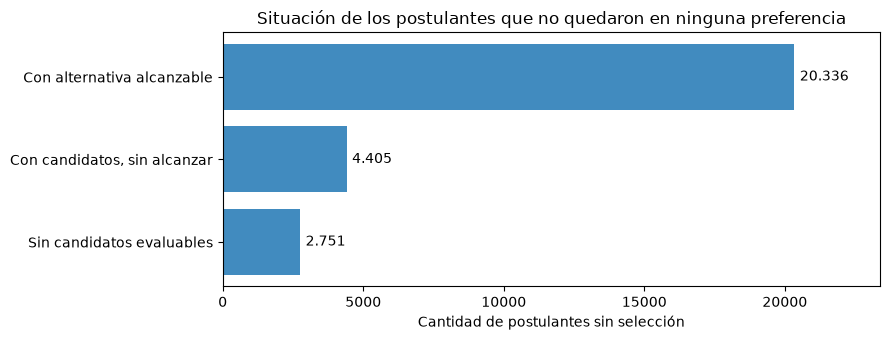

In [3]:
orden_estados = ["Con alternativa alcanzable", "Con candidatos, sin alcanzar", "Sin candidatos evaluables"]
valores = [tabla_estados.loc[e, "Estudiantes"] for e in orden_estados]

fig, ax = plt.subplots(figsize=(9, 3.5))
barras = ax.barh(orden_estados[::-1], valores[::-1], color="#1f77b4", alpha=0.85)
ax.set_xlabel("Cantidad de postulantes sin selección")
ax.set_title("Situación de los postulantes que no quedaron en ninguna preferencia")
ax.bar_label(barras, labels=[f"{v:,}".replace(",", ".") for v in valores[::-1]], padding=4)
ax.set_xlim(0, max(valores) * 1.15)
plt.tight_layout()
plt.show()

El 73,97% superaba el corte de al menos un programa de su área de interés con matrícula bajo las vacantes informadas. Del 26% restante, la mayor parte (16,02%) sí tenía programas candidatos pero no alcanzó ninguno, y un 10,01% no tenía ningún programa comparable que evaluar.

Entre quienes tenían candidatos, el grupo que **no** alcanzó ninguno presenta un mejor puntaje promedio más alto (713,4) que el grupo que sí lo logró (619,7). El resultado no depende solo del nivel de puntaje, sino de la selectividad de las carreras a las que ese puntaje apunta.

## 7.3 Contraste de la hipótesis

La hipótesis de la formulación afirma que la proporción con alternativa alcanzable es **mayor** en establecimientos particulares pagados que en públicos (Corporación Municipal, Municipal y SLEP). Hasta ahora se habían comparado las seis dependencias por separado, que no es lo mismo.

In [4]:
contraste = base[base["grupo_hipotesis"].isin(["Part. Pagado", "Publico"])]

tabla_hip = contraste.groupby("grupo_hipotesis")["y"].agg(["size", "sum"])
tabla_hip.columns = ["N", "Con alternativa"]
tabla_hip["%"] = (tabla_hip["Con alternativa"] / tabla_hip["N"] * 100).round(2)

# Intervalo de Wilson: mas confiable que el normal cuando la proporcion se aleja de 0,5
ic_inf, ic_sup = proportion_confint(tabla_hip["Con alternativa"], tabla_hip["N"],
                                    alpha=0.05, method="wilson")
tabla_hip["IC 95% inf"] = (ic_inf * 100).round(2)
tabla_hip["IC 95% sup"] = (ic_sup * 100).round(2)

tabla_hip

,N,Con alternativa,%,IC 95% inf,IC 95% sup
grupo_hipotesis,,,,,
Part. Pagado,2601,1478,56.82,54.91,58.72
Publico,8792,6935,78.88,78.01,79.72


In [5]:
pagado = tabla_hip.loc["Part. Pagado"]
publico = tabla_hip.loc["Publico"]

diferencia = pagado["%"] - publico["%"]
z, p_valor = proportions_ztest([pagado["Con alternativa"], publico["Con alternativa"]],
                               [pagado["N"], publico["N"]])

odds_pagado = pagado["Con alternativa"] / (pagado["N"] - pagado["Con alternativa"])
odds_publico = publico["Con alternativa"] / (publico["N"] - publico["Con alternativa"])

print(f"Diferencia (Part. Pagado - Publico): {diferencia:.2f} puntos porcentuales")
print(f"Razon de odds: {odds_pagado/odds_publico:.3f}")
print(f"Test de dos proporciones: z = {z:.2f}, p = {p_valor:.2e}")

Diferencia (Part. Pagado - Publico): -22.06 puntos porcentuales
Razon de odds: 0.352
Test de dos proporciones: z = -22.48, p = 6.18e-112


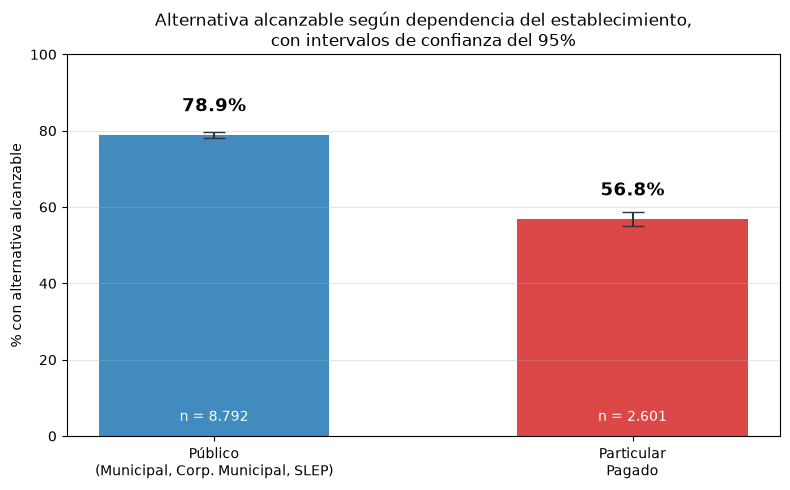

In [6]:
# Grafico del contraste: dos barras con sus intervalos. Se ordenan con Publico
# primero para que la caida de Particular Pagado se lea de izquierda a derecha.
grupos = ["Publico", "Part. Pagado"]
etiquetas = ["Público\n(Municipal, Corp. Municipal, SLEP)", "Particular\nPagado"]

valores = [tabla_hip.loc[g, "%"] for g in grupos]
error_inf = [tabla_hip.loc[g, "%"] - tabla_hip.loc[g, "IC 95% inf"] for g in grupos]
error_sup = [tabla_hip.loc[g, "IC 95% sup"] - tabla_hip.loc[g, "%"] for g in grupos]

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(etiquetas, valores, color=["#1f77b4", "#d62728"], alpha=0.85, width=0.55)
ax.errorbar(etiquetas, valores, yerr=[error_inf, error_sup],
            fmt="none", ecolor="#333333", capsize=8, linewidth=1.5)

ax.set_ylabel("% con alternativa alcanzable")
ax.set_title("Alternativa alcanzable según dependencia del establecimiento,\ncon intervalos de confianza del 95%")
ax.set_ylim(0, 100)
ax.bar_label(barras, fmt="%.1f%%", padding=14, fontsize=13, fontweight="bold")

# El n de cada grupo va dentro de la barra, para no competir con el porcentaje
for i, grupo in enumerate(grupos):
    ax.text(i, 4, f'n = {tabla_hip.loc[grupo, "N"]:,}'.replace(",", "."),
            ha="center", color="white", fontsize=10)

ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Decisión documentada:** la hipótesis **no se sostiene, y el resultado corre en la dirección contraria**. La proporción con alternativa alcanzable es de 56,82% en Particular Pagado e 78,88% en establecimientos públicos: una diferencia de −22,06 puntos porcentuales, con intervalos de confianza que no se traslapan. La hipótesis se mantiene tal como fue formulada y se reporta que la evidencia la contradice; no se redefine para acomodar el resultado.

## 7.4 La dimensión socioeconómica

La pregunta de investigación menciona dependencia **y/o** nivel socioeconómico. Hasta la Evaluación 2 el decil se había cruzado con los puntajes, pero nunca con el resultado del proyecto.

In [7]:
por_decil = base[base["decil"] != 99].groupby("decil")["y"].agg(["size", "sum"])
por_decil.columns = ["N", "Con alternativa"]
por_decil["%"] = (por_decil["Con alternativa"] / por_decil["N"] * 100).round(1)

ic_inf, ic_sup = proportion_confint(por_decil["Con alternativa"], por_decil["N"],
                                    alpha=0.05, method="wilson")
por_decil["IC 95% inf"] = (ic_inf * 100).round(1)
por_decil["IC 95% sup"] = (ic_sup * 100).round(1)

no_responde = base[base["decil"] == 99]
print(f'Sin respuesta de ingreso (codigo 99): N={len(no_responde)}, '
      f'{no_responde["y"].mean()*100:.1f}% con alternativa')
print()
por_decil

Sin respuesta de ingreso (codigo 99): N=8232, 73.1% con alternativa



,N,Con alternativa,%,IC 95% inf,IC 95% sup
decil,,,,,
1,3830,2950,77.0,75.7,78.3
2,2955,2240,75.8,74.2,77.3
3,1898,1380,72.7,70.7,74.7
4,1840,1381,75.1,73.0,77.0
5,1423,1020,71.7,69.3,74.0
6,1364,999,73.2,70.8,75.5
7,2167,1678,77.4,75.6,79.1
8,1732,1330,76.8,74.7,78.7
9,1036,718,69.3,66.4,72.0


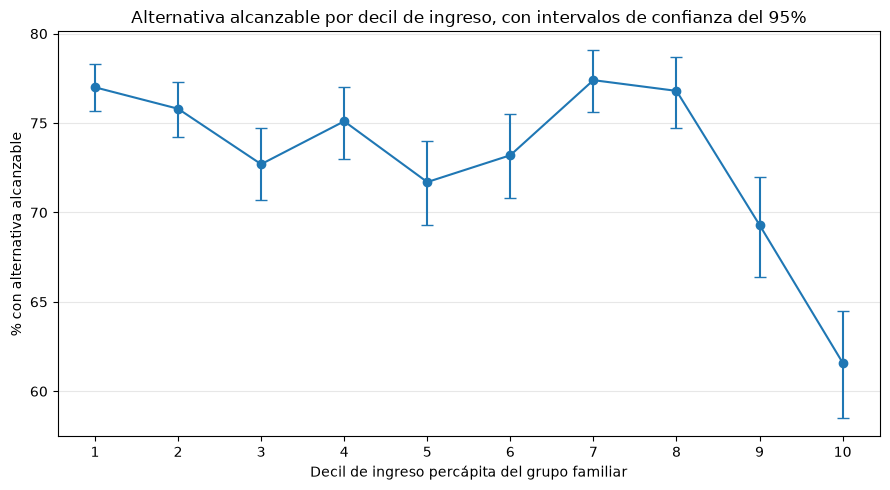

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

# Las barras de error van como distancia al punto, no como limites absolutos
error_inf = por_decil["%"] - por_decil["IC 95% inf"]
error_sup = por_decil["IC 95% sup"] - por_decil["%"]

ax.errorbar(por_decil.index, por_decil["%"], yerr=[error_inf, error_sup],
            marker="o", capsize=4, color="#1f77b4")
ax.set_xlabel("Decil de ingreso percápita del grupo familiar")
ax.set_ylabel("% con alternativa alcanzable")
ax.set_title("Alternativa alcanzable por decil de ingreso, con intervalos de confianza del 95%")
ax.set_xticks(range(1, 11))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

La relación no es monótona: entre los deciles 1 y 8 la proporción se mueve en una banda estrecha (entre 71,7% y 77,4%) y los intervalos se traslapan casi todos. La caída se inicia en el decil 9 (69,3%) y se acentúa en el 10 (61,6%).
Es el mismo patrón que muestra Particular Pagado, lo cual es esperable porque son poblaciones que se solapan. Los 8.232 que no informan ingreso se reportan aparte (73,1%) y no se imputan.

## 7.5 Primer modelo: diferencia sin ajustar

La variable respuesta es binaria, así que la herramienta que corresponde es una regresión logística. Una regresión lineal podría predecir probabilidades fuera del rango 0-1.

Este primer modelo estima la asociación **cruda** entre dependencia y resultado, sin controlar por nada. La categoría de referencia es Municipal.

In [9]:
modelo_1 = smf.logit("y ~ C(dep)", data=base.dropna(subset=["dep"])).fit(disp=0)

# Los coeficientes de una logistica estan en log-odds. Se exponencian para
# leerlos como razones de odds, que es como se reportan.
resultado_1 = pd.DataFrame({
    "OR": np.exp(modelo_1.params),
    "IC 95% inf": np.exp(modelo_1.conf_int()[0]),
    "IC 95% sup": np.exp(modelo_1.conf_int()[1]),
    "p": modelo_1.pvalues,
}).round(3)

print("Modelo 1 — referencia: Municipal")
print("n =", int(modelo_1.nobs), " | pseudo R2 =", round(modelo_1.prsquared, 4))
print()
resultado_1

Modelo 1 — referencia: Municipal
n = 27207  | pseudo R2 = 0.0156



,OR,IC 95% inf,IC 95% sup,p
Intercept,3.949,3.665,4.255,0.000
C(dep)[T.Corp. Municipal],0.845,0.737,0.970,0.016
C(dep)[T.SLEP],0.931,0.829,1.045,0.226
C(dep)[T.Corp. Adm. Delegada],0.907,0.757,1.086,0.288
C(dep)[T.Part. Subvencionado],0.711,0.655,0.773,0.000
C(dep)[T.Part. Pagado],0.333,0.299,0.371,0.000


Sin ajustar, un estudiante de Particular Pagado tiene odds de 0,333 respecto de uno municipal (IC 95% [0,299 – 0,371]): un tercio. Es la misma brecha de 7.3, ahora expresada como modelo.

## 7.6 Segundo modelo: ajustando por puntaje y nivel socioeconómico

La pregunta que importa no es si existe una diferencia bruta, sino si **persiste al comparar estudiantes equivalentes**. Se agregan el decil de ingreso (como categórico, porque el EDA mostró que la relación no es lineal) y el promedio de las pruebas obligatorias.

In [10]:
datos_modelo = base.dropna(subset=["dep", "decil_cat", "ptje_obligatorias"])

modelo_2 = smf.logit("y ~ C(dep) + C(decil_cat) + ptje_obligatorias",
                     data=datos_modelo).fit(disp=0)

resultado_2 = pd.DataFrame({
    "OR": np.exp(modelo_2.params),
    "IC 95% inf": np.exp(modelo_2.conf_int()[0]),
    "IC 95% sup": np.exp(modelo_2.conf_int()[1]),
    "p": modelo_2.pvalues,
}).round(3)

print("Modelo 2 — referencia: Municipal, decil 1")
print("n =", int(modelo_2.nobs), " | pseudo R2 =", round(modelo_2.prsquared, 4))
print()
resultado_2

Modelo 2 — referencia: Municipal, decil 1
n = 27207  | pseudo R2 = 0.1162



,OR,IC 95% inf,IC 95% sup,p
Intercept,178.861,149.271,214.316,0.000
C(dep)[T.Corp. Municipal],1.042,0.899,1.207,0.587
C(dep)[T.SLEP],0.858,0.759,0.970,0.015
C(dep)[T.Corp. Adm. Delegada],0.818,0.677,0.988,0.037
C(dep)[T.Part. Subvencionado],0.903,0.827,0.987,0.024
C(dep)[T.Part. Pagado],1.033,0.909,1.174,0.618
C(decil_cat)[T.2],1.007,0.892,1.136,0.909
C(decil_cat)[T.3],0.988,0.863,1.132,0.867
C(decil_cat)[T.4],1.098,0.954,1.263,0.192
C(decil_cat)[T.5],0.914,0.788,1.060,0.235


**El efecto de Particular Pagado desaparece.** Pasa de `OR = 0,333` a `OR = 1,033`, con un intervalo de [0,909 – 1,174] que contiene el 1 y un p de 0,618. Ninguno de los deciles resulta distinguible del decil 1 una vez incluido el puntaje.

Lo que sí queda es el puntaje: `OR = 0,993` por punto. A **mayor** puntaje, **menor** probabilidad de tener una alternativa alcanzable. Diez puntos más reducen las odds cerca de un 7%.

El pseudo R² sube de 0,016 a 0,116: casi todo el poder explicativo lo aporta el puntaje, no la dependencia.

## 7.7 Qué significa en probabilidades

Las razones de odds son difíciles de leer. Se traducen a probabilidad predicha, fijando a todos los estudiantes en el mismo decil y el mismo puntaje, para ver qué queda de la brecha.

In [11]:
escenario = pd.DataFrame({"dep": pd.Categorical(ORDEN_DEP, categories=ORDEN_DEP)})
escenario["decil_cat"] = pd.Categorical(["3"] * len(ORDEN_DEP), categories=CATEGORIAS_DECIL)
escenario["ptje_obligatorias"] = datos_modelo["ptje_obligatorias"].median()

prediccion = modelo_2.get_prediction(escenario).summary_frame(alpha=0.05)

# El nombre de estas columnas cambia entre versiones de statsmodels.
# Se resuelve por nombre para que el notebook no dependa de una version puntual.
cols = {nombre.lower(): nombre for nombre in prediccion.columns}
col_prob = cols.get("predicted", cols.get("mean"))
col_inf = cols.get("ci_lower", cols.get("mean_ci_lower"))
col_sup = cols.get("ci_upper", cols.get("mean_ci_upper"))

observado = base.groupby("DEP_NOMBRE")["y"].mean().reindex(ORDEN_DEP) * 100

comparacion = pd.DataFrame({
    "Observado %": observado.values.round(1),
    "Ajustado %": (prediccion[col_prob].values * 100).round(1),
    "IC 95% inf": (prediccion[col_inf].values * 100).round(1),
    "IC 95% sup": (prediccion[col_sup].values * 100).round(1),
    "Puntaje promedio": base.groupby("DEP_NOMBRE")["ptje_obligatorias"].mean().reindex(ORDEN_DEP).round(0).values,
}, index=ORDEN_DEP)

print(f'Escenario: decil 3, puntaje obligatorias = {escenario["ptje_obligatorias"].iloc[0]:.0f}')
print()
comparacion

Escenario: decil 3, puntaje obligatorias = 556



,Observado %,Ajustado %,IC 95% inf,IC 95% sup,Puntaje promedio
Municipal,79.8,80.5,78.3,82.5,542.0
Corp. Municipal,76.9,81.1,78.5,83.5,569.0
SLEP,78.6,78.0,75.5,80.3,533.0
Corp. Adm. Delegada,78.2,77.2,73.4,80.5,533.0
Part. Subvencionado,73.7,78.8,76.9,80.7,580.0
Part. Pagado,56.8,81.0,78.6,83.2,722.0


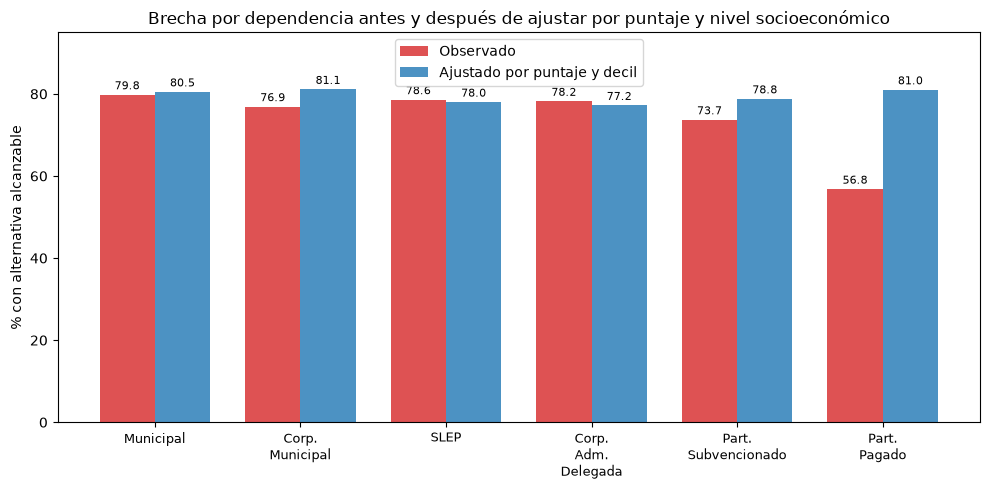

In [12]:
x = np.arange(len(ORDEN_DEP))
ancho = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - ancho/2, comparacion["Observado %"], ancho,
            label="Observado", color="#d62728", alpha=0.8)
b2 = ax.bar(x + ancho/2, comparacion["Ajustado %"], ancho,
            label="Ajustado por puntaje y decil", color="#1f77b4", alpha=0.8)

ax.set_ylabel("% con alternativa alcanzable")
ax.set_title("Brecha por dependencia antes y después de ajustar por puntaje y nivel socioeconómico")
ax.set_xticks(x)
ax.set_xticklabels([d.replace(" ", "\n") for d in ORDEN_DEP], fontsize=9)
ax.bar_label(b1, fmt="%.1f", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.1f", padding=2, fontsize=8)
ax.legend()
ax.set_ylim(0, 95)
plt.tight_layout()
plt.show()

**Decisión documentada:** al comparar estudiantes con el mismo decil y el mismo puntaje, las seis dependencias quedan entre 77,2% y 81,1%. La brecha observada de 23 puntos se cierra.

Esto **no** significa que la dependencia no importe. El puntaje no es un factor ajeno que había que descontar: es el canal por el que opera la diferencia. Los estudiantes de Particular Pagado promedian 722 puntos contra 542 de los municipales, apuntan a carreras más selectivas, y son esas carreras las que no dejan cupos sin llenar. En términos de la clase 4, el puntaje es un **mediador**, no un confusor.

La lectura correcta es: la menor proporción de alternativas en Particular Pagado se explica por el puntaje y el nivel socioeconómico de esos estudiantes, no por un efecto del tipo de establecimiento independiente de ellos. Es una asociación descrita, no una relación causal establecida.

## 7.8 El mecanismo: cuántas alternativas hay disponibles

Si la explicación es que los estudiantes de Particular Pagado persiguen carreras con menos sustitutos, eso debería verse directamente en cuántos programas candidatos tiene cada uno. Se modela el número de oportunidades como variable respuesta.

Es un conteo, así que corresponde una regresión de Poisson. Los datos están sobredispersos (la varianza supera con holgura a la media), por lo que se usan errores estándar robustos.

In [13]:
datos_poisson = base.dropna(subset=["dep", "ptje_obligatorias"])

print("n_oportunidades — media:", round(datos_poisson["n_oportunidades"].mean(), 1),
      "| varianza:", round(datos_poisson["n_oportunidades"].var(), 1))

# Modelo crudo: solo dependencia
poisson_1 = smf.poisson("n_oportunidades ~ C(dep)",
                        data=datos_poisson).fit(disp=0, cov_type="HC1")

# Modelo ajustado: se agregan puntaje y amplitud de la lista de preferencias
poisson_2 = smf.poisson("n_oportunidades ~ C(dep) + ptje_obligatorias + n_carreras_distintas",
                        data=datos_poisson).fit(disp=0, cov_type="HC1")

def tabla_irr(modelo):
    return pd.DataFrame({
        "IRR": np.exp(modelo.params),
        "IC 95% inf": np.exp(modelo.conf_int()[0]),
        "IC 95% sup": np.exp(modelo.conf_int()[1]),
    }).round(3)

print()
print("Crudo — referencia: Municipal")
print(tabla_irr(poisson_1))
print()
print("Ajustado por puntaje y amplitud de la lista")
print(tabla_irr(poisson_2))

n_oportunidades — media: 17.1 | varianza: 449.9

Crudo — referencia: Municipal
                                  IRR  IC 95% inf  IC 95% sup
Intercept                      21.707      20.955      22.485
C(dep)[T.Corp. Municipal]       0.842       0.786       0.902
C(dep)[T.SLEP]                  0.863       0.817       0.912
C(dep)[T.Corp. Adm. Delegada]   0.746       0.683       0.814
C(dep)[T.Part. Subvencionado]   0.757       0.727       0.788
C(dep)[T.Part. Pagado]          0.521       0.489       0.554

Ajustado por puntaje y amplitud de la lista
                                  IRR  IC 95% inf  IC 95% sup
Intercept                      30.441      28.464      32.554
C(dep)[T.Corp. Municipal]       0.873       0.822       0.928
C(dep)[T.SLEP]                  0.848       0.809       0.889
C(dep)[T.Corp. Adm. Delegada]   0.765       0.701       0.835
C(dep)[T.Part. Subvencionado]   0.875       0.846       0.905
C(dep)[T.Part. Pagado]          0.893       0.845       0.944
ptje_obl

Sin ajustar, un estudiante de Particular Pagado evalúa **la mitad** de las oportunidades que uno municipal (`IRR = 0,521`, IC 95% [0,489 – 0,554]). En promedio son 11,3 programas contra 21,7.

Al controlar por puntaje y por cuántas carreras distintas incluyó en su lista, el efecto se atenúa fuertemente pero no se anula: `IRR = 0,893`. Es decir, la mayor parte del déficit de alternativas se explica por el puntaje y por listas más angostas, y queda un remanente cercano al 11% asociado a la dependencia misma.

Este modelo convierte en estimación con intervalo lo que en la Evaluación 2 era una interpretación plausible sin medir.

## 7.9 Análisis de sensibilidad

El resultado central usa la comparación estricta `puntaje > corte`. Un estudiante con puntaje exactamente igual al menor seleccionado queda clasificado como insuficiente, lo que es discutible.

In [14]:
estricto = (base["n_supera"] > 0).sum()
con_empate = (base["n_supera_con_empate"] > 0).sum()

sensibilidad = pd.DataFrame({
    "Criterio": ["puntaje > corte (estricto)", "puntaje >= corte (incluye empate)"],
    "Con alternativa": [estricto, con_empate],
    "%": [round(estricto/len(base)*100, 2), round(con_empate/len(base)*100, 2)],
})

sensibilidad

,Criterio,Con alternativa,%
0,puntaje > corte (estricto),20336,73.97
1,puntaje >= corte (incluye empate),20337,73.97


La diferencia es de un caso en 27.492. El resultado no depende del criterio de empate, así que se conserva la comparación estricta y se deja constancia de la verificación.

## 7.10 Síntesis de la sección

- **La hipótesis no se sostiene y se invierte.** 56,82% en Particular Pagado contra 78,88% en establecimientos públicos, una diferencia de 22 puntos porcentuales con intervalos que no se traslapan.
- **La brecha se explica por el puntaje, no por la dependencia.** Al comparar estudiantes con el mismo decil y puntaje, las seis dependencias quedan entre 77,2% y 81,1% y el efecto de Particular Pagado deja de ser distinguible de cero (OR = 1,033, IC [0,909 – 1,174]).
- **A mayor puntaje, menor probabilidad de tener alternativa** (OR = 0,993 por punto). Quienes rinden mejor apuntan a carreras más selectivas, que son las que no dejan vacantes sin llenar.
- **El nivel socioeconómico muestra el mismo patrón de extremo:** plano entre los deciles 1 y 8, con una caída a 61,6% en el decil 10.
- **El déficit de alternativas de Particular Pagado es real y medido:** la mitad de oportunidades que un estudiante municipal, y un remanente de ~11% que persiste tras controlar por puntaje y amplitud de la lista.

## Uso de Inteligencia Artificial

Se utilizó **Claude (Anthropic)** como asistente para la construcción de este notebook: la especificación de los modelos, la elección de errores estándar robustos ante sobredispersión, la traducción de razones de odds a probabilidades predichas y la redacción de las interpretaciones. La hipótesis, la definición del grupo de contraste y la decisión de no redefinirla tras conocer los resultados son del equipo, así como la verificación de cada cifra reportada. Todas las cifras son reproducibles sobre `data/processed/base_no_seleccionados.csv`, generado por la Sección 6 a partir de las bases públicas declaradas.